In [1]:
import random
from numpy import pi
import numpy as np

# Use these lines to choose your own arbitrary state vector and normalize it.
# a = 2
# b = (1+1j)
# norm = np.sqrt(a*np.conjugate(a)+b*np.conjugate(b))
# a = a/norm
# b = b/norm
# print(a,b)

# Use these lines if you would rather look at at random spin orientations.
a = random.random()
b = random.random()
norm = np.sqrt(a * np.conjugate(a) + b * np.conjugate(b))
a = a / norm
b = b / norm
print(a, b)

0.6651129482321781 0.7467427710355822


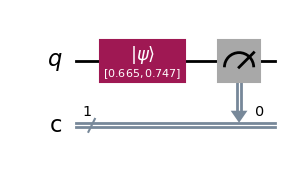

In [2]:
from qiskit.circuit import QuantumRegister, ClassicalRegister, QuantumCircuit, Parameter

# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

# Initialize the quantum state
qc.initialize([a, b])
qc.measure(0, 0)
qc.draw("mpl")

In [3]:
# Load IBM Quantum Compute Service
from qiskit_ibm_runtime import QiskitRuntimeService

# Syntax for first saving your token.  Delete these lines after saving your credentials.
# QiskitRuntimeService.save_account(channel='ibm_quantum_platform',
# instance = '<YOUR_IBM_INSTANCE_CRN>', token='<YOUR-API_KEY>', overwrite=True, set_as_default=True)
# service = QiskitRuntimeService(channel='ibm_quantum_platform')

# Syntax for specifying a channel and instance (if you need to change from the default set above)
# service = QiskitRuntimeService(channel='<channel name here>',
# instance="<your instance name here>")

# Load saved credentials
service = QiskitRuntimeService()

In [4]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler

# Use the least busy backend, specify options as needed
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
backend = service.least_busy()
print(backend.name)

ibm_marrakesh


In [5]:
# Transpile the circuit and optimize for running on the quantum computer selected
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
qc_ibm = pm.run(qc)

In [7]:
# Specify that we want to use only a single shot, to represent a single measurement of a spin in a
# SG device.
num_shots = 1

# Evaluate the problem using a QPU via Qiskit IBM Runtime
# The best practice is to use a session as shown below. This is available to Premium Plan, Flex
# Plan, and On-Prem (IBM Quantum Platform API) Plan users.
with Session(backend=backend) as session:
    sampler = Sampler(mode=session)
    dist = sampler.run([qc_ibm], shots=num_shots).result()
session.close()
counts = dist[0].data.c.get_counts()

# Open users can still carry out this experiment, but without making use of a session, meaning
# repeated queuing is possible.
# from qiskit_ibm_runtime import Batch,
# batch = Batch(backend=backend)
# sampler = Sampler(mode=batch)
# dist = sampler.run([qc_ibm], shots=num_shots).result()
# Close the batch because no context manager was used.
# batch.close()
# counts = dist[0].data.c.get_counts()

RequestsApiError: '400 Client Error: Bad Request for url: https://quantum.cloud.ibm.com/api/v1/sessions. {"errors":[{"code":1352,"message":"You are not authorized to run a session when using the open plan.","solution":"Create an instance of a different plan type or use a different [execution mode](https://quantum.cloud.ibm.com/docs/guides/execution-modes).","more_info":"https://cloud.ibm.com/apidocs/quantum-computing#error-handling"}],"trace":"99232812-2fb5-4f46-b360-b2c01ba076aa"}\n'